In [4]:
# Importing standard Qiskit libraries
from qiskit import QuantumCircuit, transpile
from qiskit.tools.jupyter import *
from qiskit.visualization import *
from ibm_quantum_widgets import *

# qiskit-ibmq-provider has been deprecated.
# Please see the Migration Guides in https://ibm.biz/provider_migration_guide for more detail.
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Estimator, Session, Options

# Loading your IBM Quantum account(s)
service = QiskitRuntimeService(channel="ibm_quantum")

# Invoke a primitive. For more details see https://qiskit.org/documentation/partners/qiskit_ibm_runtime/tutorials.html
# result = Sampler("ibmq_qasm_simulator").run(circuits).result()

In [5]:
from qiskit import QuantumCircuit, Aer, transpile
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.visualization import array_to_latex
from numpy.random import randint
import matplotlib.pyplot as plt
import numpy as np
import math

In [6]:
def encode_basis_choice(alice_bases):
    encode_basis_choice = []
    for i in range(len(alice_bases)):
        if alice_bases[i] == 0: # Prepare qubit in Z-basis
            encode_basis_choice.append("Z") 
        else: # Prepare qubit in X-basis
            encode_basis_choice.append("X")
    return encode_basis_choice


In [7]:
#Alice encrypts qubits
def encode_message(bits, bases):
    message = []
    for i in range(n):
        qc = QuantumCircuit(1,1)
        if bases[i] == 0: # Prepare qubit in Z-basis
            if bits[i] == 0:
                pass 
            else:
                qc.x(0)
        else: # Prepare qubit in X-basis
            if bits[i] == 0:
                qc.h(0)
            else:
                qc.x(0)
                qc.h(0)
        qc.barrier()
        message.append(qc)
    return message

In [8]:
def measure_message(message, bases):
    backend = Aer.get_backend('aer_simulator')
    measurements = []
    for q in range(n):
        if bases[q] == 0: # measuring in Z-basis
            message[q].measure(0,0)
        if bases[q] == 1: # measuring in X-basis
            message[q].h(0)
            message[q].measure(0,0)
        aer_sim = Aer.get_backend('aer_simulator')
        result = aer_sim.run(message[q], shots=1, memory=True).result()
        measured_bit = int(result.get_memory()[0])
        measurements.append(measured_bit)
    return measurements

In [9]:
#step 4
def remove_garbage(a_bases, b_bases, bits):
    good_bits = []
    for q in range(n):
        if a_bases[q] == b_bases[q]:
            # If both used the same basis, add
            # this to the list of 'good' bits
            good_bits.append(bits[q])
    return good_bits

In [10]:
#step 5: Bob and Alice compare random selection of their key bits
def sample_bits(bits, selection):
    sample = []
    for i in selection:
        # use np.mod to make sure the
        # bit we sample is always in 
        # the list range
        i = np.mod(i, len(bits))
        # pop(i) removes the element of the
        # list at index 'i'
        sample.append(bits.pop(i))
    return sample

In [11]:
#calculate qber by measuring hamming_weight/total no. of bits
def calc_qber(bob_sample, alice_sample):
    hamming_weight = 0
    for i in range(len(bob_sample)):
        if bob_sample[i] != alice_sample[i]:
            hamming_weight = hamming_weight + 1
    qber = hamming_weight / len(bob_sample) *100
    return qber

In [12]:
#calculate Shannon entropy
def calc_entropy(key):
    no_1s = 0
    no_0s = 0
    n=len(key)
    for i in range(len(key)):
        if key[i]== 0:
            no_0s += 1
        else:
            no_1s += 1
    p_no_1s=(no_1s)/n
    p_no_0s=(no_0s)/n
    
    # Ensure that the logarithm arguments are not zero
    p_no_1s = p_no_1s if p_no_1s != 0 else 1
    p_no_0s = p_no_0s if p_no_0s != 0 else 1
    
    h_key =  p_no_1s*math.log2(p_no_1s)+ p_no_0s*math.log2(p_no_0s)
    return -h_key 

In [13]:
#calculate joint entropy
def joint_entropy(alice_key, bob_key):
    joint_key = list(zip(alice_key, bob_key)) #creates n-tuple
    total_entries = len(joint_key)
    
    # Count occurrences of each tuple
    n_00 = joint_key.count((0, 0))
    n_10 = joint_key.count((1, 0))
    n_01 = joint_key.count((0, 1))
    n_11 = joint_key.count((1, 1))
    
    #calculate probabilities
    p_00 = n_00/total_entries
    p_01 = n_01/total_entries
    p_10 = n_10/total_entries
    p_11 = n_11/total_entries
    
    # Ensure that the logarithm arguments are not zero
    p_00 = p_00 if p_00 != 0 else 1
    p_01 = p_01 if p_01 != 0 else 1
    p_10 = p_10 if p_10 != 0 else 1
    p_11 = p_11 if p_11 != 0 else 1
    
    h_joint = p_00 * math.log2(p_00) + p_10 * math.log2(p_10) + p_01 * math.log2(p_01) + p_11 * math.log2(p_11)
    return -h_joint

In [14]:
def calc_mutual_info(alice_key, eve_key):
    h_mutual = calc_entropy(alice_key) + calc_entropy(eve_key) - joint_entropy(alice_key, eve_key)
    return h_mutual

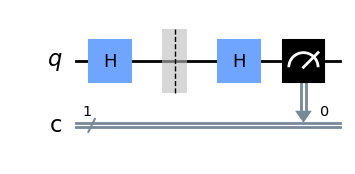

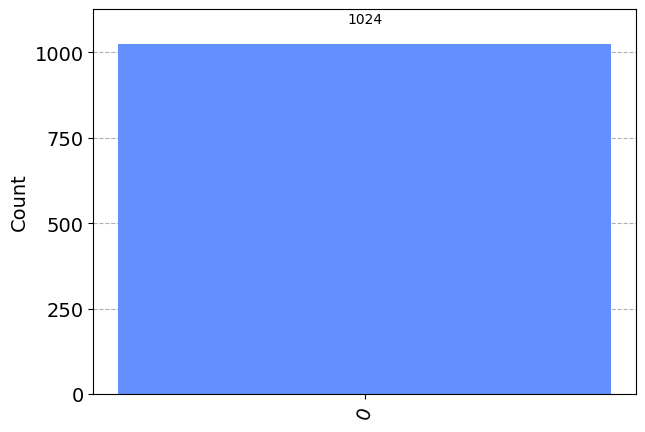

In [15]:
qc = QuantumCircuit(1,1) # 1 quantum bit and 1 classical bit
# Alice prepares qubit in state |+>
qc.h(0) #applies H gate on 0 qubit
qc.barrier() #visual indicator of the grouping of a circuit section
# Alice now sends the qubit to Bob
# who measures it in the X-basis
qc.h(0)
qc.measure(0,0)

# Draw and simulate circuit
display(qc.draw())
aer_sim = Aer.get_backend('aer_simulator')
job = aer_sim.run(qc)
plot_histogram(job.result().get_counts())

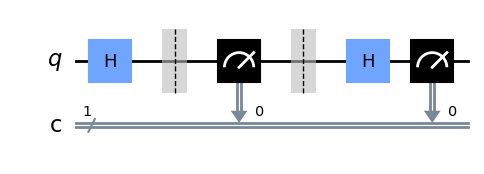

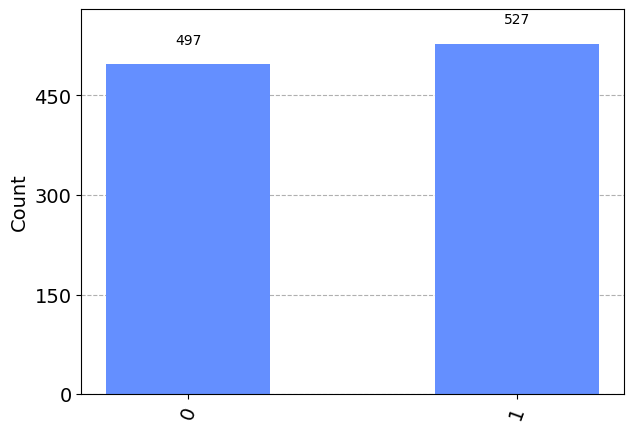

In [16]:
qc = QuantumCircuit(1,1)
# Alice prepares qubit in state |+>
qc.h(0)
qc.barrier()
# Alice now sends the qubit to Bob
# but Eve intercepts and tries to read it
qc.measure(0, 0)
qc.barrier()
# Eve then passes this on to Bob
# who measures it in the X-basis
qc.h(0)
qc.measure(0,0)

# Draw and simulate circuit
display(qc.draw())
aer_sim = Aer.get_backend('aer_simulator')
job = aer_sim.run(qc)
plot_histogram(job.result().get_counts())

In [17]:
# BB84 without eve
np.random.seed(seed=0)
n = 100

# Step 1
# Alice generates bits
alice_bits = randint(2, size=n)

# Step 2
# Create an array to tell us which qubits
# are encoded in which bases
alice_bases = randint(2, size=n)
encoding_basis = encode_basis_choice(alice_bases)
message = encode_message(alice_bits, alice_bases)


# Step 3
# Decide which basis to measure in:
bob_bases = randint(2, size=n)
decoding_basis = encode_basis_choice(bob_bases)
bob_results = measure_message(message, bob_bases)


# Step 4
alice_key = remove_garbage(alice_bases, bob_bases, alice_bits)
bob_key = remove_garbage(alice_bases, bob_bases, bob_results)


# Step 5
sample_size = 15
bit_selection = randint(n, size=sample_size)
bob_sample = sample_bits(bob_key, bit_selection)
alice_sample = sample_bits(alice_key, bit_selection)

#print results
print("Key sent by Alice:".ljust(30), np.array2string(alice_bits, max_line_width=60), "\n")

print("Random string for Alice's basis choice:".ljust(30), np.array2string(alice_bases, max_line_width=60), "\n")
print("Random string for Bob's basis choice:".ljust(30), np.array2string(bob_bases, max_line_width=60), "\n")

# Convert encoding_basis to a NumPy array
encoding_basis_np = np.array(encoding_basis)
decoding_basis_np = np.array(decoding_basis)

print("Encoding basis chosen by Alice:".ljust(30), np.array2string(encoding_basis_np, max_line_width=60), "\n")
print("Decoding basis chosen by Bob:".ljust(30), np.array2string(decoding_basis_np, max_line_width=60), "\n")

#convert bob_results to Numpy array
bob_results_np = np.array(bob_results)
print("Key received by Bob: \n".ljust(30), np.array2string(bob_results_np, max_line_width=60), "\n")

# Convert encoding_basis to a NumPy array
alice_key_np = np.array(alice_key)
bob_key_np = np.array(bob_key)

print("Key retained by Alice (after sifting): \n".ljust(30), np.array2string(alice_key_np, max_line_width=60), "\n")
print("Key retained by Bob (after sifting): \n".ljust(30), np.array2string(bob_key_np, max_line_width=60), "\n")
print("key length = %i \n" % len(alice_key))

print("Bob's sample:  {}\n".format(bob_sample))
print("Alice's sample: {}\n".format(alice_sample))

Key sent by Alice:             [0 1 1 0 1 1 1 1 1 1 1 0 0 1 0 0 0 0 0 1 0 1 1 0 0 1 1 1 1
 0 1 0 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 0
 0 1 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 1 1 0 1 0 0 1 0 1 1 1 1
 1 1 0 1 1 0 0 1 0 0 1 1 0] 

Random string for Alice's basis choice: [1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 1 0 1 0 1 1 1 1 1 0 1 1 1
 1 0 1 1 0 0 1 0 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0 1 1 1
 0 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 0 0 1 0 0] 

Random string for Bob's basis choice: [1 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 1 1 1 0 0 1
 1 1 1 0 0 0 1 1 0 1 0 0 1 0 1 1 1 1 0 0 0 1 1 1 0 1 1 1 1
 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0 0 0 1 0 1 0 1 1 0 0 0 1 0
 0 1 1 1 1 0 1 0 0 0 0 1 1] 

Encoding basis chosen by Alice: ['X' 'Z' 'Z' 'X' 'Z' 'Z' 'Z' 'X' 'X' 'Z' 'X' 'Z' 'Z' 'Z'
 'Z' 'Z' 'X' 'Z' 'X' 'Z' 'X' 'X' 'X' 'X' 'X' 'Z' 'X' 'X'
 'X' 'X' 'Z' 'X' 'X' 'Z' 'Z' 'X' 'Z' 'Z' 'Z' 'Z' 'X' 'X'
 'Z' 'Z' 'X' 'Z' 'X' 'X' 'X' 'X' 'Z' 'Z' 'Z' 'X' 'Z' 'X'
 'X' 'X' '

In [18]:
print("qber: %i" % calc_qber(bob_sample, alice_sample))
print("Alice's entropy: %i" % calc_entropy(alice_key))
print("Bob's entropy: %i" % calc_entropy(bob_key))
print("Alice and Bob's joint entropy: %i" % joint_entropy(alice_key, bob_key))
print("Alice and Bob's mutual entropy: %i" % calc_mutual_info(alice_key, bob_key))

qber: 0
Alice's entropy: 0
Bob's entropy: 0
Alice and Bob's joint entropy: 0
Alice and Bob's mutual entropy: 0


In [19]:
# BB84 with Eve
np.random.seed(seed=3)
n = 100

# Step 1
# Alice generates bits
alice_bits = randint(2, size=n)

# Step 2
# Create an array to tell us which qubits
# are encoded in which bases
alice_bases = randint(2, size=n)
encoding_basis = encode_basis_choice(alice_bases)
message = encode_message(alice_bits, alice_bases)

## Interception!!
eve_bases = randint(2, size=n)
eve_decoding_bases = encode_basis_choice(eve_bases)
intercepted_message = measure_message(message, eve_bases)

# Step 3
# Decide which basis to measure in:
bob_bases = randint(2, size=n)
decoding_basis = encode_basis_choice(bob_bases)
bob_results = measure_message(message, bob_bases)


# Step 4
alice_key = remove_garbage(alice_bases, bob_bases, alice_bits)
bob_key = remove_garbage(alice_bases, bob_bases, bob_results)
eve_key =  remove_garbage(alice_bases, bob_bases, intercepted_message)

# Step 5
sample_size = 15 # Change this to something lower and see if 
                 # Eve can intercept the message without Alice
                 # and Bob finding out
bit_selection = randint(n, size=sample_size)
bob_sample = sample_bits(bob_key, bit_selection)
alice_sample = sample_bits(alice_key, bit_selection)

#print results
print("Key sent by Alice:".ljust(30), np.array2string(alice_bits, max_line_width=60), "\n")

print("Random string for Alice's basis choice:".ljust(30), np.array2string(alice_bases, max_line_width=60), "\n")
print("Random string for Eve's basis choice:".ljust(30), np.array2string(eve_bases, max_line_width=60), "\n")
print("Random string for Bob's basis choice:".ljust(30), np.array2string(bob_bases, max_line_width=60), "\n")

# Convert encoding_basis to a NumPy array
encoding_basis_np = np.array(encoding_basis)
decoding_basis_np = np.array(decoding_basis)
eve_decoding_np = np.array(eve_decoding_bases)

print("Encoding basis chosen by Alice:".ljust(30), np.array2string(encoding_basis_np, max_line_width=60), "\n")
print("Decoding basis chosen by Eve:".ljust(30), np.array2string(eve_decoding_np, max_line_width=60), "\n")
print("Decoding basis chosen by Bob:".ljust(30), np.array2string(decoding_basis_np, max_line_width=60), "\n")

#convert bob_results to Numpy array
eve_results_np = np.array(intercepted_message)
bob_results_np = np.array(bob_results)
print("Key received by Eve: \n".ljust(30), np.array2string(eve_results_np, max_line_width=60), "\n")
print("Key received by Bob: \n".ljust(30), np.array2string(bob_results_np, max_line_width=60), "\n")


# Convert encoding_basis to a NumPy array
alice_key_np = np.array(alice_key)
bob_key_np = np.array(bob_key)
eve_key_np = np.array(eve_key)

print("Key retained by Alice (after sifting): \n".ljust(30), np.array2string(alice_key_np, max_line_width=60), "\n")
print("Key retained by Bob (after sifting): \n".ljust(30), np.array2string(bob_key_np, max_line_width=60), "\n")
print("Key retained by Eve (after sifting): \n".ljust(30), np.array2string(eve_key_np, max_line_width=60), "\n")
print("key length = %i \n" % len(alice_key))

print("Bob's sample:  {}\n".format(bob_sample))
print("Alice's sample: {}\n".format(alice_sample))

Key sent by Alice:             [0 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0
 0 0 1 0 1 1 0 1 0 0 1 1 0 0 1 0 1 0 1 1 1 1 0 1 0 0 1 1 1
 0 0 0 1 0 0 0 1 0 0 1 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1
 1 0 1 0 0 0 0 0 1 1 0 1 1] 

Random string for Alice's basis choice: [1 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0 0 1 1
 0 0 1 1 1 1 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0
 0 1 0 1 0 1 1 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 1 1 1 0 0 0 0
 0 0 1 0 1 0 0 0 1 0 1 1 1] 

Random string for Eve's basis choice: [0 1 1 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 0 1 1 0 1 0 1 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 0 0 1
 0 1 0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 1 0 1 0 1 1 0 1 1 0 1 1
 0 0 0 1 1 1 0 1 0 0 0 1 0] 

Random string for Bob's basis choice: [1 0 0 0 1 0 1 1 1 1 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 1 1 0
 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 1 0 0 0 1 0 1 1 1 0 0 0 1
 1 0 0 0 0 0 0 1 0 1 0 1 1 1 1 0 0 0 0 1 0 0 1 0 1 0 0 1 0
 0 1 1 1 0 0 1 1 1 1 1 1 0] 

Encoding basis chosen by 

In [20]:
if bob_sample != alice_sample:
    print("Eve's interference was detected.")
else:
    print("Eve went undetected!")
qber=calc_qber(bob_sample, alice_sample)
entropy_a = calc_entropy(alice_key)
entropy_b = calc_entropy(bob_key)
entropy_ab = joint_entropy(alice_key, bob_key)
mutual_ae=calc_mutual_info(alice_key, eve_key)
mutual_be=calc_mutual_info(bob_key, eve_key)
key_retention = len(bob_key)/n *100
print(f"QBER: {qber}")
print(f"Key Retention: {key_retention}")
print("Alice's entropy: %i" % entropy_a)
print("Bob's entropy: %i" % entropy_b)
print("Alice and Bob's joint entropy: %i" % entropy_ab)
print("Alice and Eve's mutual entropy: %i" % mutual_ae)
print("Bob and Eve's mutual entropy: %i" % mutual_ae)

Eve's interference was detected.
QBER: 33.33333333333333
Key Retention: 37.0
Alice's entropy: 0
Bob's entropy: 0
Alice and Bob's joint entropy: 1
Alice and Eve's mutual entropy: 0
Bob and Eve's mutual entropy: 0


In [21]:
# Comparison of a sample set of size 15
np.random.seed(seed=3)
n = 1000

# Step 1
# Alice generates bits
alice_bits = randint(2, size=n)

# Step 2
# Create an array to tell us which qubits
# are encoded in which bases
alice_bases = randint(2, size=n)
encoding_basis = encode_basis_choice(alice_bases)
message = encode_message(alice_bits, alice_bases)

## Interception!!
eve_bases = randint(2, size=n)
eve_decoding_bases = encode_basis_choice(eve_bases)
intercepted_message = measure_message(message, eve_bases)

# Step 3
# Decide which basis to measure in:
bob_bases = randint(2, size=n)
decoding_basis = encode_basis_choice(bob_bases)
bob_results = measure_message(message, bob_bases)


# Step 4
alice_key = remove_garbage(alice_bases, bob_bases, alice_bits)
bob_key = remove_garbage(alice_bases, bob_bases, bob_results)
eve_key =  remove_garbage(alice_bases, bob_bases, intercepted_message)

# Step 5
sample_size = 200 # Change this to something lower and see if 
                 # Eve can intercept the message without Alice
                 # and Bob finding out
bit_selection = randint(n, size=sample_size)
bob_sample = sample_bits(bob_key, bit_selection)
alice_sample = sample_bits(alice_key, bit_selection)

In [22]:
if bob_sample != alice_sample:
    print("Eve's interference was detected.")
else:
    print("Eve went undetected!")
qber=calc_qber(bob_sample, alice_sample)
qber=calc_qber(bob_sample, alice_sample)
alice_entropy = calc_entropy(alice_key)
bob_entropy = calc_entropy(bob_key) 
joint_entropy_a_b = joint_entropy(alice_key, bob_key)
mutual_info_alice_eve = calc_mutual_info(alice_key, eve_key)
mutual_info_bob_eve = calc_mutual_info(bob_key, eve_key)

print(f"QBER: {qber}")
print(f"Alice's entropy: {alice_entropy}")
print(f"Bob's entropy: {bob_entropy}")
print(f"Alice and Bob's joint entropy: {joint_entropy_a_b}")
print(f"Alice and Eve's mutual entropy: {mutual_info_alice_eve}" )
print(f"Bob and Eve's mutual entropy:{mutual_info_bob_eve }")

Eve's interference was detected.
QBER: 39.0
Alice's entropy: 0.9967916319816366
Bob's entropy: 0.999871756640849
Alice and Bob's joint entropy: 1.9637080415351906
Alice and Eve's mutual entropy: -0.002311267481573509
Bob and Eve's mutual entropy:-0.0024724979688433013


In [23]:
#measure how much of message is retained
key_retention = len(bob_key)/n *100
print(key_retention)
print(len(bob_key))
#print(intercepted_message)

30.0
300


In [24]:
# Example usage:
key1 = [1, 0, 1, 1]
key2 = [1, 0, 1, 0]
a = calc_entropy(key1)
print("Entropy (key1):", a)
b = calc_entropy(key2)
print("Entropy (key2):", b)
entropy = joint_entropy(key1, key2)
print("Joint Entropy:", entropy)
mutual_info = calc_mutual_info(key1, key2)
print("Mutual information:", entropy)

Entropy (key1): 0.8112781244591328
Entropy (key2): 1.0
Joint Entropy: 1.5
Mutual information: 1.5


In [25]:
alice_eve_mutual_info = calc_mutual_info(alice_key, eve_key)
bob_eve_mutual_info = calc_mutual_info(bob_key, eve_key)
print("Mutual information between Alice and Eve:", entropy)
print("Mutual information between Bob and Eve:", entropy)

Mutual information between Alice and Eve: 1.5
Mutual information between Bob and Eve: 1.5


In [ ]:
def run_simulation(iterations):
    for iteration in tqdm_notebook(range(iterations), desc="Running simulations", leave=False):
        clear_output(wait=True)  # Clear the previous output
        print(f"Running simulation {iteration + 1}/{iterations}")
        np.random.seed(seed=3)
        n = 1000
        sample_size = 100 

        # Step 1
        # Alice generates bits
        alice_bits = randint(2, size=n)

        # Step 2
        # Create an array to tell us which qubits
        # are encoded in which bases
        alice_bases = randint(2, size=n)
        encoding_basis = encode_basis_choice(alice_bases)
        message = encode_message(alice_bits, alice_bases)

        ## Interception!!
        eve_bases = randint(2, size=n)
        eve_decoding_bases = encode_basis_choice(eve_bases)
        intercepted_message = measure_message(message, eve_bases)

        # Step 3
        # Decide which basis to measure in:
        bob_bases = randint(2, size=n)
        decoding_basis = encode_basis_choice(bob_bases)
        bob_results = measure_message(message, bob_bases)
    

        # Step 4
        alice_key = remove_garbage(alice_bases, bob_bases, alice_bits)
        bob_key = remove_garbage(alice_bases, bob_bases, bob_results)
        eve_key =  remove_garbage(alice_bases, bob_bases, intercepted_message)

        # Step 5
      # Change this to something lower and see if 
                 # Eve can intercept the message without Alice
                 # and Bob finding out
        bit_selection = randint(n, size=sample_size)
        bob_sample = sample_bits(bob_key, bit_selection)
        alice_sample = sample_bits(alice_key, bit_selection)